In [2]:
import pandas as pd
from glob import glob
import biotite.structure as struc
import biotite.structure.io.pdbx as pdbx 
from plinder.core.structure.superimpose import superimpose_chain 
import re
import numpy as np
from tqdm.auto import tqdm
import seaborn as sns
import useful_rdkit_utils as uru

In [3]:
df = pd.read_csv("uniprot_ids.csv")
df

,Name,UniProt ID
0,AHR,P35869
1,PXR,O75469
2,CYP1A2,P05177
3,CYP2D6,P10635
4,CYP3A4,P08684
5,CYP2C9,P11712


In [4]:
def get_ca_rmsd(fixed, mobile):
    new_mobile, transform, fixed_idx, mobile_idx = superimpose_chain(fixed, mobile)
    new_mobile_ca = new_mobile[mobile_idx]
    fixed_ca = fixed[fixed_idx]
    return new_mobile, struc.rmsd(fixed_ca, new_mobile_ca)


def read_cif_chain(filepath,chain="A"):
    pdbx_file = pdbx.CIFFile.read(filepath)
    atom_array = pdbx.get_structure(pdbx_file, model=1, include_bonds=True)
    protein_mask = struc.filter_amino_acids(atom_array)
    atom_array = atom_array[protein_mask]
    chain_mask = (atom_array.chain_id == chain)
    chain_A = atom_array[chain_mask]
    return chain_A


def get_of3_chains(target):
    chain_list = []
    name_re = re.compile("/([A-Z,0-9,_,a-z]+).cif")
    for filename in glob(f"OF3_inputs/{target}/seed_42/*.cif"):
        pdb = name_re.findall(filename)[0]
        chain_list.append([pdb,read_cif_chain(filename)])
    return chain_list        

def get_boltz_chains(target):
    chain_list = []
    name_re = re.compile("/([A-Z,0-9,_,a-z]+).cif")
    for filename in glob(f"Boltz_inputs/boltz_results_{target}/predictions/{target}/*.cif"):
        pdb = name_re.findall(filename)[0]
        chain_list.append([pdb,read_cif_chain(filename)])
    return chain_list

def get_ref_chains(target):
    chain_list = []
    name_re = re.compile("/([A-Z,0-9]+).cif")
    for filename in glob(f"../CIF/{target}/*.cif"):   
        pdb = name_re.findall(filename)[0]
        chain_list.append([pdb,read_cif_chain(filename)])
    return chain_list

In [12]:
ref_chain_list = [x[1] for x in get_ref_chains("AHR")]
boltz_chain_list = [x[1] for x in get_boltz_chains("AHR")]

[len(x) for x in ref_chain_list],[len(x) for x in boltz_chain_list]

/home/pwalters/miniforge3/envs/rdkit_2025_12/lib/python3.11/site-packages/biotite/structure/io/pdbx/convert.py:461: UserWarning: Attribute 'auth_atom_id' not found within 'atom_site' category. The fallback attribute 'label_atom_id' will be used instead
  warnings.warn(


([10143, 10143, 2787], [6757, 6757, 6757, 6757, 6757])

In [6]:
result_list = []
for protein in df.Name:
    pred_chain_list = get_boltz_chains(protein)
    ref_chain_list = get_ref_chains(protein)
    for ref_name, ref_chain in tqdm(ref_chain_list):
        rms_list = []
        for pred_name, pred_chain in pred_chain_list:
            _, rmsd = get_ca_rmsd(ref_chain, pred_chain)
            rms_list.append(rmsd)
        result_list.append([protein,ref_name,np.argmin(rms_list),min(rms_list),"Boltz-2"])

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/122 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [7]:
count_df = pd.DataFrame(result_list,columns=["Protein","pdb","best_idx","RMSD","Method"])
count_dict = {}
for protein, count in uru.value_counts_df(count_df,"Protein").values:
    count_dict[protein] = f"{protein}\n{count}"

In [8]:
for protein in df.Name:
    pred_chain_list = get_of3_chains(protein)
    ref_chain_list = get_ref_chains(protein)
    for ref_name, ref_chain in tqdm(ref_chain_list):
        rms_list = []
        for pred_name, pred_chain in pred_chain_list:
            _, rmsd = get_ca_rmsd(ref_chain, pred_chain)
            rms_list.append(rmsd)
        if len(rms_list):
            result_list.append([protein,ref_name,np.argmin(rms_list),min(rms_list),"OF-3"])

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/122 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [9]:
result_df = pd.DataFrame(result_list,columns=["Protein","pdb","best_idx","RMSD","Method"])
result_df['count_str'] = [count_dict[x] for x in result_df.Protein]

Text(0, 0.5, 'C-$\\alpha$ RMSD')

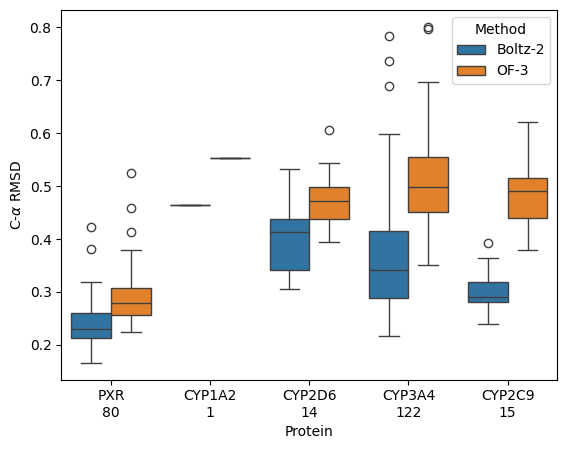

In [10]:
ax = sns.boxplot(x="count_str",y="RMSD",hue="Method",data=result_df.query("Protein != 'AHR'"))
ax.set_xlabel("Protein")
ax.set_ylabel("C-$\\alpha$ RMSD")